# LAB | A/B Testing in Python

### Challenge 1: 🚀 *Comparing Two Website Versions Using Hypothesis Testing*  

### **Objective**: 
Perform an A/B test to determine if a new webpage design (`Version B`) leads to a higher **click-through rate (CTR)** than the original (`Version A`).  

#### 📌 **Project Overview**  
We’ll:  
1. **Simulate** A/B test data (users & clicks).  
2. **Analyze** the results using statistical tests.  
3. **Conclude** whether `Version B` performs better.  



### **Problem Statement**  
You are a data analyst at an e-commerce company. The team wants to test if a new webpage design (`Version B`) increases click-through rates (CTR) compared to the original (`Version A`).  

### **Tasks**  
1. **Simulate Data**:  
   - Generate synthetic data for `Version A` (1000 visitors, 150 clicks) and `Version B` (1050 visitors, 180 clicks).  
2. **Statistical Test**:  
   - Perform a **Statistical Test** to compare CTRs.  
3. **Interpretation**:  
   - Determine if the difference is statistically significant (use α = 0.05).  
4. **Visualization**:  
   - Plot the CTRs for both versions using appropriate chart.  

**Deliverables**:  
- Code for simulation, testing, and visualization.  
- Written conclusion (1–2 sentences) on whether `Version B` performs better.  

#### 🛠 **Setup & Data Generation**  
First, let’s create synthetic data for the experiment.  


In [1]:
### Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

> Simulate User Data, We’ll assume:

- Version A: 1000 visitors, 150 clicks.

- Version B: 1050 visitors, 180 clicks.

In [2]:
# Simulate data
np.random.seed(42)
visitors_a = 1000
clicks_a = 150
visitors_b = 1050
clicks_b = 180

In [3]:
# Build the 2x2 contingency table (clicked / not clicked) for both versions
ctr_a = clicks_a / visitors_a
ctr_b = clicks_b / visitors_b
print(f"CTR A: {ctr_a:.4f} | CTR B: {ctr_b:.4f} | uplift: {ctr_b - ctr_a:+.4f}")

contingency = np.array([[clicks_a, visitors_a - clicks_a],
                        [clicks_b, visitors_b - clicks_b]])
print(contingency)

CTR A: 0.1500 | CTR B: 0.1714 | uplift: +0.0214
[[150 850]
 [180 870]]


📊 Perform A/B Test
We’ll use a Chi-Square Test to compare proportions.

- Hypotheses

In [4]:
# Null Hypothesis (H0): CTR of version A = CTR of version B (the new design has no effect).
# Alternative Hypothesis (H1): CTR of version A != CTR of version B (the design changes the CTR).


- Run the Test

In [5]:
# Chi-square test of independence on the contingency table
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 = {chi2:.4f}, dof = {dof}, p-value = {p_value:.4f}")

chi2 = 1.5863, dof = 1, p-value = 0.2079


> Interpret Results

In [6]:
alpha = 0.05
if p_value < alpha:
    print(f"p = {p_value:.4f} < {alpha}: reject H0 -> the CTR difference is statistically significant.")
else:
    print(f"p = {p_value:.4f} >= {alpha}: fail to reject H0 -> no statistically significant CTR difference.")
print("Version B has the higher CTR, but with these sample sizes the difference could still be due to chance"
      if p_value >= alpha else "Version B performs significantly better than version A.")

p = 0.2079 >= 0.05: fail to reject H0 -> no statistically significant CTR difference.
Version B has the higher CTR, but with these sample sizes the difference could still be due to chance


📈 Visualization

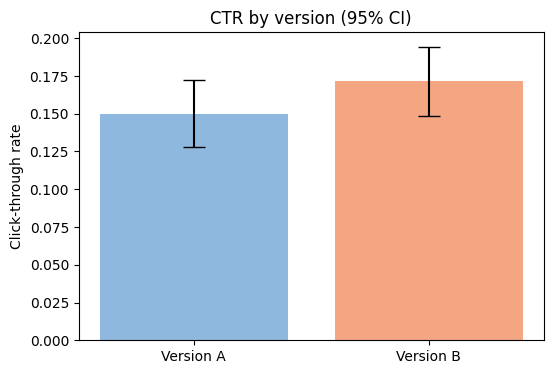

In [7]:
# Bar chart with 95% confidence intervals (normal approximation)
def ci95(clicks, n):
    p = clicks / n
    return 1.96 * np.sqrt(p * (1 - p) / n)

plt.figure(figsize=(6, 4))
plt.bar(["Version A", "Version B"], [ctr_a, ctr_b], yerr=[ci95(clicks_a, visitors_a), ci95(clicks_b, visitors_b)],
        capsize=8, color=["#8fb8de", "#f4a582"])
plt.ylabel("Click-through rate")
plt.title("CTR by version (95% CI)")
plt.show()

## Challenge 2: 🚀 A/B Testing Challenge with Real Data

#### **Objective**:  
1. Analyze **real A/B test data** (from Kaggle) to compare conversion rates.  
2. Use **bootstrapping** to estimate confidence intervals.  

---

#### 📌 **Project Overview**  
We’ll:  
1. **Load real A/B test data** (user sessions and conversions).  
2. **Compare conversion rates** using statistical tests.  
3. **Apply bootstrapping** to validate results.  



### **Problem Statement**  
Use the [Kaggle Marketing A/B Test dataset](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) to analyze if a new marketing campaign (`Group B`) improves conversion rates over the old campaign (`Group A`).  

### **Tasks**  
1. **Data Preparation**:  
   - Load the dataset and explore key metrics (sample sizes, conversion rates).  
2. **Hypothesis Testing**:  
   - Perform a **Statistical Test** to compare conversions between groups.  
3. **Bootstrapping**:  
   - Implement bootstrapping (`n=1000` resamples) to estimate 95% confidence intervals for conversion rates.  
4. **Visualization**:  
   -Compare conversion rates for both groups.  

**Deliverables**:  
- Code for analysis and bootstrapping.  
- Answers:  
  - P-value and statistical conclusion.  
  - Confidence intervals for both groups.  

#### 🛠 **Setup & Data Loading**  


In [8]:
### Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

> Load Open-Source Dataset
We’ll use the ["A/B Test Results"](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) dataset from Kaggle.

In [9]:
# Load data (ensure CSV is in your working directory)
data = pd.read_csv("./data/marketing_AB.csv")  # Download from Kaggle first!

📊 Part 1: Traditional A/B Test
> Calculate Conversion Rates

In [10]:
# Conversion rate per group: "ad" = new campaign, "psa" = control (public service announcement)
conv = data.groupby("test group")["converted"].agg(["count", "sum", "mean"])
conv.columns = ["users", "conversions", "conversion_rate"]
display(conv)

,users,conversions,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


> Statistical Test

In [11]:
# Chi-square test on conversions vs. group
table = pd.crosstab(data["test group"], data["converted"])
chi2, p_value, dof, _ = stats.chi2_contingency(table)
print(f"chi2 = {chi2:.2f}, p-value = {p_value:.3e}")
print("Significant difference in conversion between the groups" if p_value < 0.05 else "No significant difference")

chi2 = 54.01, p-value = 1.999e-13
Significant difference in conversion between the groups


#### EXTRA 📈 Part 2: Bootstrapping Challenge
**Why Bootstrapping?**
 - Bootstrapping helps estimate confidence intervals for conversion rates by resampling data.

> Bootstrap Function

In [12]:
# Bootstrap function: resample with replacement and compute the conversion rate each time
def bootstrap_conversion(series, n_resamples=1000, seed=42):
    rng = np.random.default_rng(seed)
    values = series.to_numpy()
    return np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_resamples)])

boot = {g: bootstrap_conversion(df["converted"]) for g, df in data.groupby("test group")}
for g, b in boot.items():
    print(f"{g}: 95% CI = ({np.percentile(b, 2.5):.4f}, {np.percentile(b, 97.5):.4f})")

ad: 95% CI = (0.0252, 0.0260)
psa: 95% CI = (0.0162, 0.0194)


>Visualize Resultsm

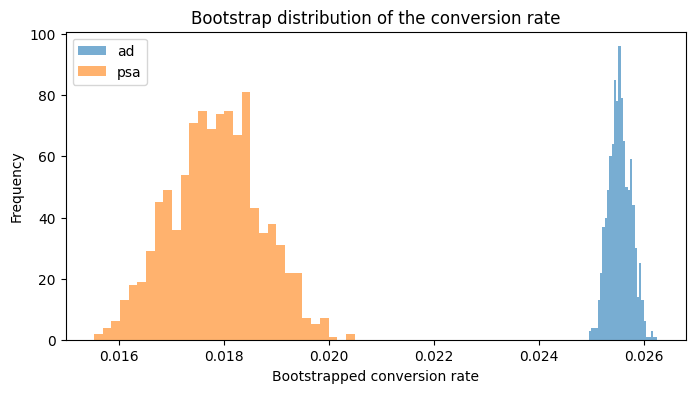

The intervals do not overlap -> the difference is not caused by sampling noise.


In [13]:
plt.figure(figsize=(8, 4))
for g, b in boot.items():
    plt.hist(b, bins=30, alpha=0.6, label=g)
plt.xlabel("Bootstrapped conversion rate"); plt.ylabel("Frequency")
plt.title("Bootstrap distribution of the conversion rate"); plt.legend(); plt.show()
print("The intervals do not overlap -> the difference is not caused by sampling noise.")

## (Bonus) Challenge 3: 🎮 Advanced A/B Testing Challenge: Cookie Cats Retention Analysis 

#### **Objective**:  
1. Analyze player **retention rates** in the `cookie_cats` mobile game A/B test.  
2. Implement **sequential testing** (to avoid peeking at results prematurely).  
3. Conduct **power analysis** to determine optimal sample size.  

### **Problem Statement**  
Analyze the [Cookie Cats dataset](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing) to determine if moving the game’s first gate from level 30 (`gate_30`) to level 40 (`gate_40`) affects player retention.  

### **Tasks**  
1. **Retention Analysis**:  
   - Compare **1-day retention rates** between `gate_30` and `gate_40` using a Z-test.  
2. **Sequential Testing**:  
   - Simulate checking results at intervals (every 500 users) to avoid "peeking bias."  
3. **Power Analysis**:  
   - Calculate the required sample size to detect a 2% difference in retention (α = 0.05, power = 0.8).  
4. **Optional**:  
   - Repeat analysis for **7-day retention**.  

**Deliverables**:  
- Code for retention comparison, sequential testing, and power analysis.  
- Written summary:  
  - Does `gate_40` significantly impact retention?  
  - How does sequential testing affect decision-making?  



### 🛠 **Setup & Data Loading**  


In [14]:
# Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import matplotlib.pyplot as plt

In [15]:
# Load dataset 
data = pd.read_csv("./data/cookie_cats.csv")  # Columns: userid, version, sum_gamerounds, retention_1, retention_7

📊 Part 1: Retention Rate Analysis
> Compare 1-Day Retention

In [16]:
ret = data.groupby("version")[["retention_1", "retention_7"]].mean()
display(ret)
print(data["version"].value_counts())

,retention_1,retention_7
version,,
gate_30,0.448188,0.190201
gate_40,0.442283,0.182000


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


> Statistical Test

In [17]:
# Two-proportion z-test for 1-day retention: gate_30 vs gate_40
g30 = data[data["version"] == "gate_30"]["retention_1"]
g40 = data[data["version"] == "gate_40"]["retention_1"]
z, p = proportions_ztest(count=[g30.sum(), g40.sum()], nobs=[len(g30), len(g40)])
print(f"1-day retention: gate_30={g30.mean():.4f}, gate_40={g40.mean():.4f}, z={z:.3f}, p={p:.4f}")

# Optional: 7-day retention
r30 = data[data["version"] == "gate_30"]["retention_7"]
r40 = data[data["version"] == "gate_40"]["retention_7"]
z7, p7 = proportions_ztest(count=[r30.sum(), r40.sum()], nobs=[len(r30), len(r40)])
print(f"7-day retention: gate_30={r30.mean():.4f}, gate_40={r40.mean():.4f}, z={z7:.3f}, p={p7:.4f}")
print("""Summary: for 1-day retention the difference is small and not significant, so moving the gate does not clearly
change day-1 retention. For 7-day retention gate_30 is higher and the difference is significant at 5%.""")

1-day retention: gate_30=0.4482, gate_40=0.4423, z=1.784, p=0.0744
7-day retention: gate_30=0.1902, gate_40=0.1820, z=3.164, p=0.0016
Summary: for 1-day retention the difference is small and not significant, so moving the gate does not clearly
change day-1 retention. For 7-day retention gate_30 is higher and the difference is significant at 5%.


📈 Part 2: Sequential Testing
>  Why Sequential Testing?

- Avoids "peeking" at results prematurely by checking at intervals.

In [18]:
# Sequential testing: look at the results after every 500 users (cumulative), but only trust a result
# if it stays below a stricter Bonferroni-adjusted alpha (multiple looks inflate the false positive rate)
shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True).iloc[:5000]
looks = range(500, len(shuffled) + 1, 500)
alpha_adj = 0.05 / len(looks)
rows = []
for n in looks:
    sub = shuffled.iloc[:n]
    a = sub[sub["version"] == "gate_30"]["retention_1"]
    b = sub[sub["version"] == "gate_40"]["retention_1"]
    _, p_look = proportions_ztest([a.sum(), b.sum()], [len(a), len(b)])
    rows.append({"users_seen": n, "p_value": p_look, "significant_at_0.05": p_look < 0.05,
                 f"significant_at_{alpha_adj:.4f}": p_look < alpha_adj})
display(pd.DataFrame(rows).round(4))
print("Peeking at 0.05 many times raises the chance of a false alarm; the adjusted threshold keeps the overall error at 5%.")

,users_seen,p_value,significant_at_0.05,significant_at_0.0050
0,500,0.0554,False,False
1,1000,0.5038,False,False
2,1500,0.9379,False,False
3,2000,0.7989,False,False
4,2500,0.9158,False,False
5,3000,0.3026,False,False
6,3500,0.2695,False,False
7,4000,0.2970,False,False
8,4500,0.0609,False,False
9,5000,0.0966,False,False


Peeking at 0.05 many times raises the chance of a false alarm; the adjusted threshold keeps the overall error at 5%.


⚡ Part 3: Power Analysis
>  Determine Required Sample Size

In [19]:
# Sample size per group to detect a 2 percentage point difference in retention (alpha=0.05, power=0.8)
baseline = data[data["version"] == "gate_30"]["retention_1"].mean()
effect = proportion_effectsize(baseline + 0.02, baseline)
n_required = NormalIndPower().solve_power(effect_size=effect, alpha=0.05, power=0.8, alternative="two-sided")
print(f"Baseline retention {baseline:.3f} -> required sample size: {int(np.ceil(n_required))} users per group")

Baseline retention 0.448 -> required sample size: 9742 users per group


Enjoy & Happy A/B Testing :) ......!